In [26]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

data = pd.read_csv("phishing_websites.csv")

# Split dataset for training and testing (80/20)

In [2]:
# ensures random sequence is deterministic and reproducible
random_seed = 42

# Features and target
X = data.drop('result', axis = 1)
y = data['result']

# 80/20 split for train/test
# stratify for ensures that training and testing datasets maintain same class proportions as original data set (56/44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_seed, stratify=y)

# XGBoost and Logistic Regression expects labels like 0/1, not -1/1
y_train_binary = (y_train == 1).astype(int)
y_test_binary = (y_test == 1).astype(int)

# Random Forest
----------------------------------------------------------------------------------------------------------------------------------------

In [24]:
# 200 trees in forest
# n_jobs = -1 uses all CPU cores
rf = RandomForestClassifier(
    n_estimators = 50,
    random_state = random_seed,
    n_jobs = -1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9755766621438263


In [28]:
# Store model in pickle

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

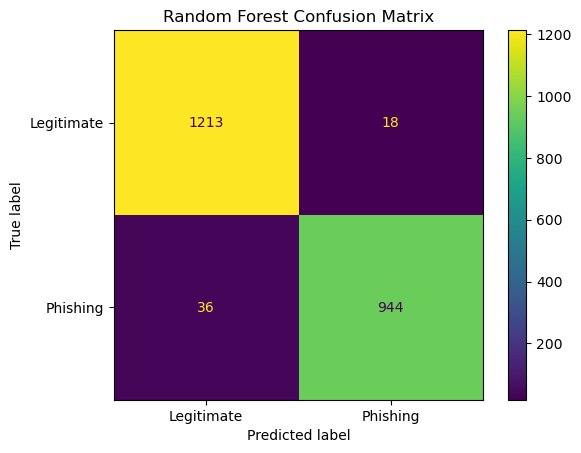

In [4]:
# Confusion Matrix to show inaccuracies
# 36 False negatives
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, -1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

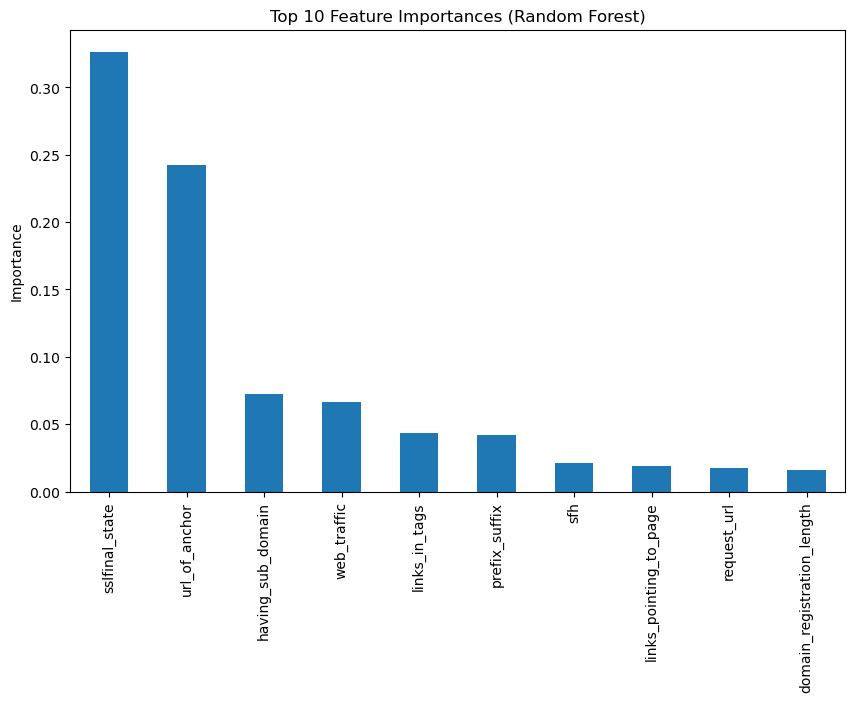

In [5]:
# 10 most important features for Random Forest
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

# XGBoost
----------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# 500 trees in forest
xgb = XGBClassifier(
    n_estimators = 500, 
    max_depth = 5,
    random_state = random_seed,
    n_jobs = -1)


xgb.fit(X_train, y_train_binary)

y_pred_xgb = xgb.predict(X_test)
accuracy = accuracy_score(y_test_binary, y_pred_xgb)
print(f"Test Accuracy: {accuracy}" )

Test Accuracy: 0.9769335142469471


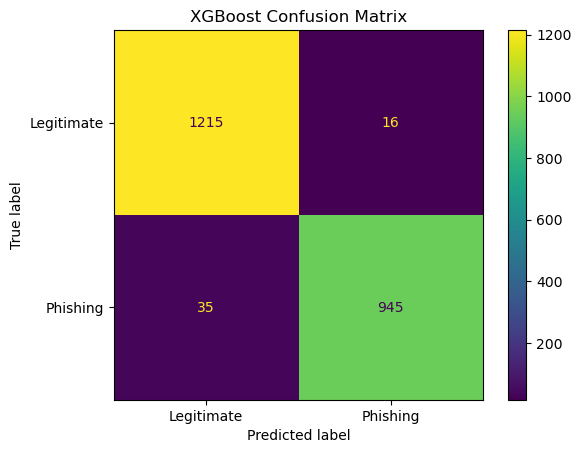

In [7]:
# Confusion Matrix to show inaccuracies
# 35 False negatives
cm = confusion_matrix(y_test_binary, y_pred_xgb, labels=[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

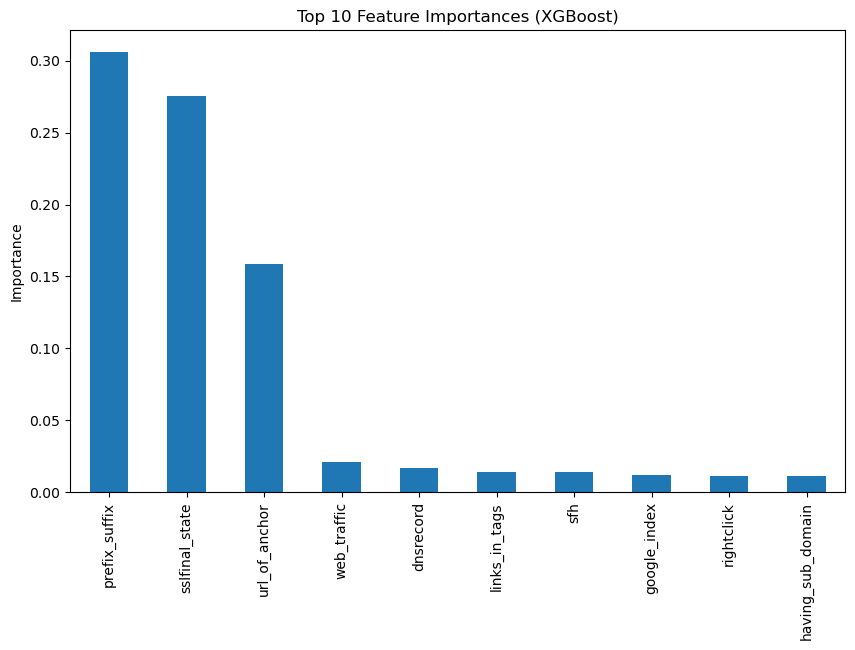

In [8]:
# 10 most important features for XGBoost
importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.ylabel("Importance")
plt.show()

# Logistic Regression
----------------------------------------------------------------------------------------------------------------------------------------

In [9]:
# Scaling is highly recommended for logistic regression (Gradient Descent converges faster)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    solver = 'liblinear',
    fit_intercept = True,
    random_state = random_seed
)

lr.fit(X_train_scaled, y_train_binary)

y_pred_lr = lr.predict(X_test_scaled)
accuracy = accuracy_score(y_test_binary, y_pred_lr)
print(f"Test Accuracy: {accuracy}" )

Test Accuracy: 0.9289914066033469


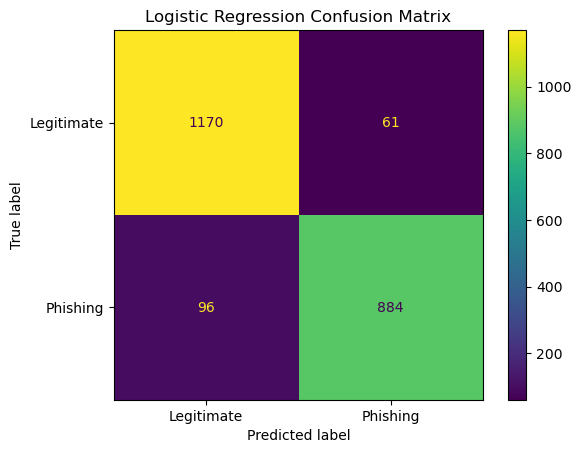

In [10]:
# Confusion Matrix to show inaccuracies
# 96 False negatives
cm = confusion_matrix(y_test_binary, y_pred_lr, labels=[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [12]:
coeffs = pd.Series(
    lr.coef_[0],
    index=X.columns
).sort_values()

# Top phishing indicators (positive coefficients)
coeffs.tail(10)

dnsrecord                 0.462796
having_sub_domain         0.485874
links_pointing_to_page    0.486165
having_ip_address         0.576810
web_traffic               0.607842
links_in_tags             0.628955
sfh                       0.642820
sslfinal_state            1.438771
prefix_suffix             2.084951
url_of_anchor             2.289976
dtype: float64

# Random Forest With Only Main Features
----------------------------------------------------------------------------

In [23]:
main_features = ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain']

# ensures random sequence is deterministic and reproducible
random_seed = 42

X_train_main = X_train[main_features]
X_test_main  = X_test[main_features]

rf_main = RandomForestClassifier(
    n_estimators=50,
    random_state=random_seed,
    n_jobs=-1
)

rf_main.fit(X_train_main, y_train)

y_pred_rf_main = rf_main.predict(X_test_main)

accuracy_main = accuracy_score(y_test, y_pred_rf_main)
print(f"Main Feature Random Forest Accuracy: {accuracy_main}")

Main Feature Random Forest Accuracy: 0.7304387155133424


In [30]:
with open("url_features_model.pkl", "wb") as f:
    pickle.dump(rf_main, f)